In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from haversine import haversine, Unit
import networkx as nx
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import LineString

airports_df = pd.read_csv('usa_airports_fuel.csv')
airports_df = airports_df.dropna(subset=['ICAO_ID'])
airports_df = airports_df.dropna(subset=['state'])
airports_df = airports_df[airports_df['state'] != 'HI']
airports_df = airports_df[airports_df['state'] != 'PR']
airports_df = airports_df[airports_df['state'] != 'VI']
airports_df = airports_df[airports_df['state'] != 'AK']
airports_df['fuel_price'] = airports_df['fuel_price'] / 3.78541
airports_df = airports_df.reset_index(drop=True)

{'shortest': [1493, 732, 735, 296, 189], 'cheapest': [1493, 2179, 604, 1363, 1345, 117, 131, 216, 162, 176, 189], 'balanced': [1493, 1504, 741, 1132, 790, 789, 756, 117, 131, 216, 245, 162, 172, 163, 176, 189]}


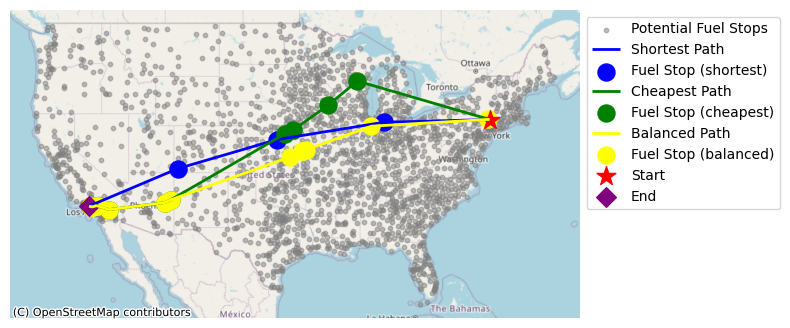

|  Selection  |                                                           ICAO_ID                                                            |                                                                                                                                                                     Airport                                                                                                                                                                      |  Total Distance  |  Refuel Cost  |
|:-----------:|:----------------------------------------------------------------------------------------------------------------------------:|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------:|:-

In [4]:
def find_closest_airport(name, airports_df):
    return airports_df['name'].iloc[
        airports_df['name'].str.lower().map(
            lambda x: len(set(x.split()) & set(name.lower().split()))
        ).argmax()
    ]

def find_optimal_routes(airports_df, start_idx, end_idx, tank_capacity, miles_per_liter):
    range_capacity = tank_capacity * miles_per_liter
    G_distance = nx.DiGraph()
    G_cost = nx.DiGraph()
    G_balanced = nx.DiGraph()
    all_airports = set([start_idx, end_idx]) | set(airports_df[airports_df['fuel_price'].notna()].index)
    
    for airport_idx in all_airports:
        G_distance.add_node(airport_idx)
        G_cost.add_node(airport_idx)
        G_balanced.add_node(airport_idx)
    
    edges_data = []
    for to_idx in all_airports - {start_idx}:
        dist = haversine(
            (airports_df.loc[start_idx, 'latitude'], airports_df.loc[start_idx, 'longitude']),
            (airports_df.loc[to_idx, 'latitude'], airports_df.loc[to_idx, 'longitude']),
            unit=Unit.MILES
        )
        
        if dist <= range_capacity:
            edges_data.append({
                'from': start_idx, 
                'to': to_idx, 
                'distance': dist, 
            })
    
    fuel_airports = airports_df[airports_df['fuel_price'].notna()].index
    for from_idx in fuel_airports:
        for to_idx in all_airports - {from_idx}:
            dist = haversine(
                (airports_df.loc[from_idx, 'latitude'], airports_df.loc[from_idx, 'longitude']),
                (airports_df.loc[to_idx, 'latitude'], airports_df.loc[to_idx, 'longitude']),
                unit=Unit.MILES
            )
            
            if dist <= range_capacity:
                to_fuel_price = airports_df.loc[to_idx, 'fuel_price']
                if pd.notna(to_fuel_price):
                    refuel_cost = dist / miles_per_liter * to_fuel_price
                else:
                    refuel_cost = float('inf')
                edges_data.append({
                    'from': from_idx, 
                    'to': to_idx, 
                    'distance': dist, 
                    'refuel_cost': refuel_cost,
                })
    
    for edge in edges_data:
        G_distance.add_edge(edge['from'], edge['to'], weight=edge['distance'])
        G_cost.add_edge(edge['from'], edge['to'], weight=edge.get('refuel_cost', 0))
    
    if edges_data:
        distances = [edge['distance'] for edge in edges_data]
        costs = [edge.get('refuel_cost', 0) for edge in edges_data]
        min_dist, max_dist = min(distances), max(distances)
        min_cost, max_cost = min(costs), max(costs)
        for edge in edges_data:
            dist = edge['distance']
            cost = edge.get('refuel_cost', 0)
            norm_dist = (dist - min_dist) / (max_dist - min_dist)
            norm_cost = (cost - min_cost) / (max_cost - min_cost)
            G_balanced.add_edge(edge['from'], edge['to'], weight=0.5 * norm_dist + 0.5 * norm_cost)

    shortest_path = nx.dijkstra_path(G_distance, start_idx, end_idx, weight='weight')
    cheapest_path = nx.dijkstra_path(G_cost, start_idx, end_idx, weight='weight')
    balanced_path = nx.dijkstra_path(G_balanced, start_idx, end_idx, weight='weight')
    
    return {
        'shortest': shortest_path,
        'cheapest': cheapest_path,
        'balanced': balanced_path
    }

def plot_routes(airports_df, routes, start_idx, end_idx):
    airports_gdf = gpd.GeoDataFrame(
        airports_df,
        geometry=gpd.points_from_xy(airports_df['longitude'], airports_df['latitude']),
        crs="EPSG:4326"
    )
    airports_gdf = airports_gdf.to_crs(epsg=3857)
    fig, ax = plt.subplots(figsize=(8, 8))
    fuel_airports = airports_gdf[airports_df['fuel_price'].notna()]
    fuel_airports.plot(ax=ax, color='grey', markersize=10, alpha=0.5, label='Potential Fuel Stops')
    
    for route_type, route, color in [
        ('shortest', routes['shortest'], 'blue'),
        ('cheapest', routes['cheapest'], 'green'),
        ('balanced', routes['balanced'], 'yellow')
    ]:
        route_coords = airports_gdf.iloc[route].geometry
        route_line = gpd.GeoSeries([LineString(route_coords)], crs=airports_gdf.crs)
        route_line.plot(ax=ax, color=color, linewidth=2, label=f'{route_type.capitalize()} Path')
        fuel_idx = route[1:-1]
        fuel_point = airports_gdf.iloc[fuel_idx]
        fuel_point.plot(ax=ax, color=color, markersize=150, 
                        label=f'Fuel Stop ({route_type})')
    
    start_point = airports_gdf.iloc[[start_idx]]
    start_point.plot(ax=ax, color='red', marker='*', markersize=200, label='Start')
    end_point = airports_gdf.iloc[[end_idx]]
    end_point.plot(ax=ax, color='purple', marker='D', markersize=100, label='End')
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def create_summary_table(airports_df, routes, miles_per_liter):
    evaluations = []
    route_types = ['shortest', 'cheapest', 'balanced']
    
    for route_type in route_types:
        route = routes[route_type]
        airport_names = []
        icao_ids = []
        total_distance = 0
        total_refuel_cost = 0

        for i in range(len(route) - 1):
            from_idx = route[i]
            to_idx = route[i+1]
            airport_names.append(airports_df.loc[from_idx, 'name'])
            icao_ids.append(airports_df.loc[from_idx, 'ICAO_ID'])
            
            dist = haversine(
                (airports_df.loc[from_idx, 'latitude'], airports_df.loc[from_idx, 'longitude']),
                (airports_df.loc[to_idx, 'latitude'], airports_df.loc[to_idx, 'longitude']),
                unit=Unit.MILES
            )
            
            total_distance += dist
            fuel_price = airports_df.loc[to_idx, 'fuel_price']
            total_refuel_cost += dist / miles_per_liter * fuel_price
        
        airport_names.append(airports_df.loc[route[-1], 'name'])
        icao_ids.append(airports_df.loc[route[-1], 'ICAO_ID'])
        
        evaluations.append({
            'Selection': route_type.capitalize(),
            'ICAO_ID': ' -> '.join(icao_ids),
            'Airport': ' -> '.join(airport_names),
            'Total Distance': total_distance,
            'Refuel Cost': total_refuel_cost,
        })
    
    results_df = pd.DataFrame(evaluations)
    return results_df
    
def save_route_to_txt(mission_data, route, filename):
    ordered_points = []
    for idx in route:
        point = mission_data[idx]
        ordered_points.append([point['latitude'], point['longitude'], 0])
    points_array = np.array(ordered_points)
    np.savetxt(filename, points_array)

def main(start_name, end_name, tank_capacity, miles_per_liter):
    start = find_closest_airport(start_name, airports_df)
    end = find_closest_airport(end_name, airports_df)
    start_idx = airports_df[airports_df['name'] == start].index[0]
    end_idx = airports_df[airports_df['name'] == end].index[0]
    
    routes = find_optimal_routes(airports_df, start_idx, end_idx, tank_capacity, miles_per_liter)
    # routes = {'shortest': [1493, 732, 735, 296, 189], 'cheapest': [1493, 2179, 604, 1363, 1345, 117, 131, 216, 162, 176, 189], 'balanced': [1493, 1504, 741, 1132, 790, 789, 756, 117, 131, 216, 245, 162, 172, 163, 176, 189]}
    print(routes)
    
    plot_routes(airports_df, routes, start_idx, end_idx)
    
    summary_table = create_summary_table(airports_df, routes, miles_per_liter)
    print(summary_table.to_markdown(index=False, colalign=['center']*5))

    return airports_df.to_dict('records'), routes['shortest']

tank_capacity = 80 # L
miles_per_liter = 10

filename = "use_case_3.txt"
mission_data, route = main(start_name="new york", end_name="Los Angeles", tank_capacity=tank_capacity, miles_per_liter=miles_per_liter)
save_route_to_txt(mission_data, route, filename=filename)